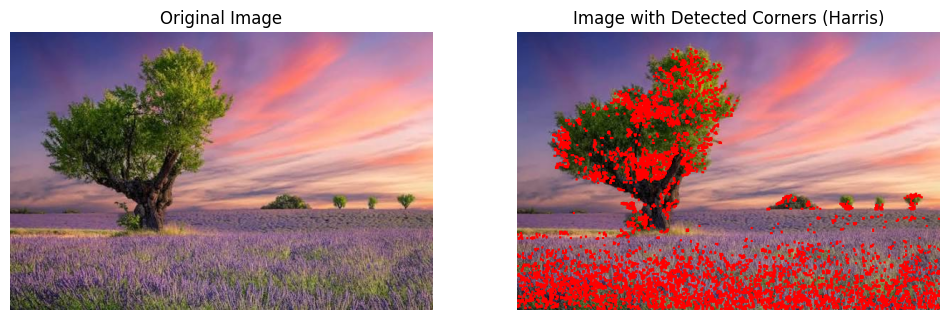

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Image Loading and Preprocessing ---
# IMPORTANT: Replace 'path/to/your/image.jpg' with the actual path to your image file.
# You can upload an image to your Colab environment or use a publicly accessible URL.
# Example: img_path = 'https://docs.opencv.org/4.x/img/blox.jpg'
# For local files, make sure the file is in the Colab session's working directory
# or provide the full path.

# For demonstration, I'll use a placeholder. Please replace it.
img_path = 'Image1.jpg' # Replace with your image path

# Try to read the image
try:
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {img_path}. Please check the path.")
except FileNotFoundError as e:
    print(e)
    print("As a fallback, using a dummy image for demonstration.")
    # Create a dummy image for demonstration if file not found
    img = np.zeros((200, 300, 3), dtype=np.uint8)
    cv2.putText(img, 'Image Not Found', (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2.putText(img, 'Please update img_path', (30, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Convert image to float32 for Harris Corner Detection
gray = np.float32(gray)

# --- Harris Corner Detection ---
# Parameters:
#   blockSize: size of neighbourhood considered for corner detection
#   ksize: Aperture parameter for the Sobel operator
#   k: Harris detector free parameter in the equation
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# Dilate to mark the corners more visibly
dst = cv2.dilate(dst, None)

# --- Visualize the Results ---
# Create a copy of the original image to draw corners on
img_corners = img.copy()

# Threshold for an optimal value, it may vary depending on the image.
# Marking corners in red
img_corners[dst > 0.01 * dst.max()] = [0, 0, 255]

# Display the original image and the image with detected corners
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_corners, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
plt.title('Image with Detected Corners (Harris)')
plt.axis('off')

plt.show()